In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from __init_py.config import dados_tratados,dados_categorizados

from sklearn.metrics import( mean_absolute_error, mean_squared_error,root_mean_squared_error,r2_score)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from auxiliares.auxiliares import dataframe_coeficientes
from auxiliares.graficos import plot_coeficientes, plot_residuos
 
sns.set_theme(palette="bright")

RANDON_STATE = 42

In [10]:
df= pd.read_parquet(dados_tratados)

df.head()

,idade,sexo,imc,pressao_media,colesterol_total,ldl,hdl,colesterol_hdl,triglicerides,glicose,target
0,59,2,32.099998,101.0,157,93.199997,38.0,4.0,4.8598,87,151
1,48,1,21.600000,87.0,183,103.199997,70.0,3.0,3.8918,69,75
2,72,2,30.500000,93.0,156,93.599998,41.0,4.0,4.6728,85,141
3,24,1,25.299999,84.0,198,131.399994,40.0,5.0,4.8903,89,206
4,50,1,23.000000,101.0,192,125.400002,52.0,4.0,4.2905,80,135


In [11]:
df["sexo"] = df["sexo"].astype("category")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   idade             442 non-null    int8    
 1   sexo              442 non-null    category
 2   imc               442 non-null    float32 
 3   pressao_media     442 non-null    float32 
 4   colesterol_total  442 non-null    int16   
 5   ldl               442 non-null    float32 
 6   hdl               442 non-null    float32 
 7   colesterol_hdl    442 non-null    float32 
 8   triglicerides     442 non-null    float32 
 9   glicose           442 non-null    int8    
 10  target            442 non-null    int16   
dtypes: category(1), float32(6), int16(2), int8(2)
memory usage: 13.6 KB


Colunas para Power Transforme

- IMC
- ldl
- hdl
- colesterol_total

coluna para inteiro

- colesterol+hdl

coluna para standardScaler

- todas demais

In [12]:
df["colesterol_hdl"]=df['colesterol_hdl'].round().astype("int")
df["colesterol_hdl"].value_counts()

colesterol_hdl
3    141
4    126
5     84
6     41
2     30
7     14
8      5
9      1
Name: count, dtype: int64

<Axes: xlabel='colesterol_hdl'>

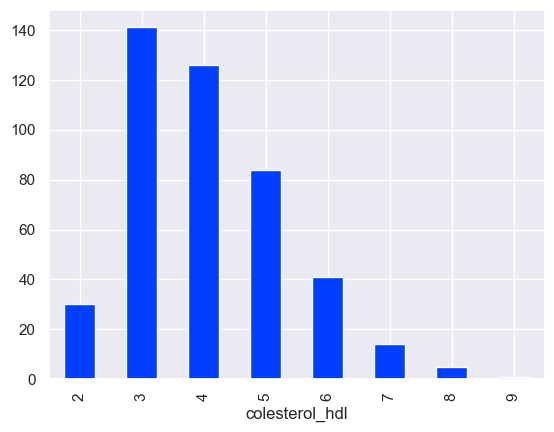

In [13]:

df["colesterol_hdl"].value_counts().sort_index().plot(kind="bar")

In [16]:
df["colesterol_hdl_cat"]= pd.cut(
    df["colesterol_hdl"],
    bins=[2,4,6,10],
    labels=["2-3","4-5","6+"],
    right=False
)

df["colesterol_hdl_cat"].value_counts().sort_index()

colesterol_hdl_cat
2-3    171
4-5    210
6+      61
Name: count, dtype: int64

In [17]:
df= df.drop(columns=["colesterol_hdl"])

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   idade               442 non-null    int8    
 1   sexo                442 non-null    category
 2   imc                 442 non-null    float32 
 3   pressao_media       442 non-null    float32 
 4   colesterol_total    442 non-null    int16   
 5   ldl                 442 non-null    float32 
 6   hdl                 442 non-null    float32 
 7   triglicerides       442 non-null    float32 
 8   glicose             442 non-null    int8    
 9   target              442 non-null    int16   
 10  colesterol_hdl_cat  442 non-null    category
dtypes: category(2), float32(5), int16(2), int8(2)
memory usage: 12.4 KB


In [ ]:
df.to_parquet(dados_categorizados, index=False)